In [ ]:
!pip install optuna lightgbm catboost xgboost scikit-learn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (precision_recall_curve, roc_auc_score,
                                     average_precision_score, recall_score,
                                     precision_score, f1_score, confusion_matrix,
                                     ConfusionMatrixDisplay, accuracy_score)
from sklearn.pipeline        import Pipeline

from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('/content/final_pre-renewal_churn_dataset.csv')

In [ ]:
print(f"Raw shape        : {df.shape}")
print(f"Columns          : {df.columns.tolist()}")
print(f"\nRenewal_Year distribution:")
print(df["Renewal_Year"].value_counts().sort_index())

print(f"\nYear-wise churn rate:")
print(df.groupby("Renewal_Year")["churn_label"].mean().apply(lambda x: f"{x:.2%}"))

Raw shape        : (112081, 61)
Columns          : ['Co_Ref', 'year_key', 'Renewal_Year', 'payment_timeframe_missing', 'Total_Renewal_Score_New', 'payment_unknown', 'Payment_Timeframe', 'Sustainability_Score', 'payment_is_bacs', 'Auto_Renewal_Score', 'Tenure_Scores', 'Current_World_Pay_Token', 'payment_is_card', 'Renewal_Score_At_Release', 'Proforma_Membership_Status', 'Discount_Amount', 'price_increase_pct', 'Gross', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Current_Anchorings', 'Last_Band', 'price_change', 'Anchoring_Score', 'Proforma_World_Pay_Token', 'Tenure_Years', '#_of_Connection', 'is_new_customer', 'Last_Connections', 'Tenure_Group', 'rc_desire_cancel_desired_to_cancel_true', 'crm_contractor_suggested_leave', 'Current_Auto_Renewal_Flag', 'crm_contractor_sentiment_score', 'Amount', 'PQQNet', 'had_rc_interaction', 'rc_Membership_Renewal_Decision', 'payment_is_worldpay', 'Band', 'had_em_interaction', 'Connection_Group', 'crm_agent_chase_count', 'crm_negative_customer_exper

In [ ]:
# STEP 2 — TRAIN / TEST SPLIT (Time-Based on renewal_month_year)

TARGET    = "churn_label"
DROP_COLS = ["Co_Ref", "year_key", "Renewal_Year", "renewal_month_year"]

# Check churn rate per renewal_month_year
print("Churn rate per renewal_month_year:")
month_stats = (
    df.groupby("renewal_month_year")["churn_label"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "n_rows"})
    .reset_index()
)

# Sort chronologically
month_stats["_sort"] = pd.to_datetime(month_stats["renewal_month_year"], format="%b-%Y")
month_stats = month_stats.sort_values("_sort").drop(columns="_sort")
month_stats["churn_rate"] = month_stats["churn_rate"].round(4)
print(month_stats.to_string(index=False))

overall_churn = df["churn_label"].mean()
print(f"\nOverall churn rate: {overall_churn:.4f}")


Churn rate per renewal_month_year:
renewal_month_year  churn_rate  n_rows
          Jan-2023      0.1164    2922
          Feb-2023      0.1222    3011
          Mar-2023      0.1263    3088
          Apr-2023      0.1078    2681
          May-2023      0.1394    2884
          Jun-2023      0.1292    3135
          Jul-2023      0.1486    2800
          Aug-2023      0.1377    2360
          Sep-2023      0.1237    2546
          Oct-2023      0.1432    2836
          Nov-2023      0.1145    3110
          Dec-2023      0.1028    1955
          Jan-2024      0.1216    3011
          Feb-2024      0.1091    3043
          Mar-2024      0.1118    3229
          Apr-2024      0.0931    2739
          May-2024      0.0872    2903
          Jun-2024      0.1026    3147
          Jul-2024      0.0871    2777
          Aug-2024      0.1029    2409
          Sep-2024      0.1082    2440
          Oct-2024      0.1069    2909
          Nov-2024      0.0923    3292
          Dec-2024      0.089

In [ ]:
# STEP 2 — TRAIN / TEST SPLIT (renewal_month_year based)
df["_sort_date"] = pd.to_datetime(df["renewal_month_year"], format="%b-%Y")

TRAIN_END  = pd.to_datetime("Dec-2024", format="%b-%Y")
TEST_START = pd.to_datetime("Jan-2025", format="%b-%Y")
TEST_END   = pd.to_datetime("Mar-2026", format="%b-%Y")  # drop Apr/May 2026

train_df = df[df["_sort_date"] <= TRAIN_END].copy()
test_df  = df[
    (df["_sort_date"] >= TEST_START) &
    (df["_sort_date"] <= TEST_END)
].copy()

# Drop sort helper
df.drop(columns=["_sort_date"], inplace=True)
train_df.drop(columns=["_sort_date"], inplace=True)
test_df.drop(columns=["_sort_date"], inplace=True)

# Drop identifier + split columns
X_train = train_df.drop(columns=[TARGET] + DROP_COLS, errors="ignore")
X_test  = test_df.drop(columns=[TARGET]  + DROP_COLS, errors="ignore")
y_train = train_df[TARGET].astype(int)
y_test  = test_df[TARGET].astype(int)

print(f"Train shape      : {X_train.shape}  | Churn rate: {y_train.mean():.4f}")
print(f"Test  shape      : {X_test.shape}   | Churn rate: {y_test.mean():.4f}")
print(f"\nTrain class counts:\n{y_train.value_counts()}")
print(f"\nTest  class counts:\n{y_test.value_counts()}")

SCALE_POS_WEIGHT = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight : {SCALE_POS_WEIGHT:.2f}")

# Verify churn rates are balanced
print(f"\nTrain months     : Jan-2023 → Dec-2024")
print(f"Test  months     : Jan-2025 → Mar-2026")
print(f"Churn rate gap   : {abs(y_train.mean() - y_test.mean()):.4f}")

Train shape      : (67220, 56)  | Churn rate: 0.1138
Test  shape      : (44440, 56)   | Churn rate: 0.0973

Train class counts:
churn_label
0    59570
1     7650
Name: count, dtype: int64

Test  class counts:
churn_label
0    40117
1     4323
Name: count, dtype: int64

scale_pos_weight : 7.79

Train months     : Jan-2023 → Dec-2024
Test  months     : Jan-2025 → Mar-2026
Churn rate gap   : 0.0165


In [ ]:
# STEP 3 — LABEL ENCODE CATEGORICALS

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Handle unseen labels in test gracefully
    X_test[col]  = X_test[col].astype(str).map(
        lambda x, le=le: le.transform([x])[0]
        if x in le.classes_ else -1
    )
    label_encoders[col] = le

print(f"Encoded {len(cat_cols)} columns.")
print(f"Final feature count: {X_train.shape[1]}")

Categorical columns: ['Proforma_Membership_Status', 'Discount_Amount', 'Proforma_Account_Stage', 'Audit_Status_Group', 'Last_Band', 'Tenure_Group', 'Band', 'Connection_Group', 'Anchor_Group']
Encoded 9 columns.
Final feature count: 56


In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name,
                   threshold=0.6, verbose=True):
    """
    Train model, evaluate on test set.
    Returns dict of metrics.
    """
    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_te)[:, 1]
    preds = (probs >= threshold).astype(int)

    pr_auc    = average_precision_score(y_te, probs)
    roc_auc   = roc_auc_score(y_te, probs)
    recall    = recall_score(y_te, preds)
    precision = precision_score(y_te, preds, zero_division=0)
    f1        = f1_score(y_te, preds)
    accuracy  = accuracy_score(y_te, preds)

    if verbose:
        print(f"\n  {model_name}")
        print(f"  PR-AUC    : {pr_auc:.4f} ")
        print(f"  ROC-AUC   : {roc_auc:.4f}")
        print(f"  Recall    : {recall:.4f}")
        print(f"  Precision : {precision:.4f}")
        print(f"  F1-Score  : {f1:.4f}")
        print(f"  Accuracy  : {accuracy:.4f}")


    return {
        "model_name" : model_name,
        "model"      : model,
        "probs"      : probs,
        "pr_auc"     : pr_auc,
        "roc_auc"    : roc_auc,
        "recall"     : recall,
        "precision"  : precision,
        "f1"         : f1,
        "accuracy"   : accuracy
    }

In [ ]:
from sklearn.impute import SimpleImputer
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy='mean')
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

print("NaNs in X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nNaNs in X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

if X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0:
    print("\nNo NaN values found in X_train and X_test after imputation. Proceeding with model training.")
else:
    print("\nWarning: NaN values still present after imputation. Please investigate.")

NaNs in X_train:
Series([], dtype: int64)

NaNs in X_test:
Series([], dtype: int64)

No NaN values found in X_train and X_test after imputation. Proceeding with model training.


In [ ]:
X_train.columns.to_list()

['payment_timeframe_missing',
 'Total_Renewal_Score_New',
 'payment_unknown',
 'Payment_Timeframe',
 'Sustainability_Score',
 'payment_is_bacs',
 'Auto_Renewal_Score',
 'Tenure_Scores',
 'Current_World_Pay_Token',
 'payment_is_card',
 'Renewal_Score_At_Release',
 'Proforma_Membership_Status',
 'Discount_Amount',
 'price_increase_pct',
 'Gross',
 'Proforma_Account_Stage',
 'Audit_Status_Group',
 'Current_Anchorings',
 'Last_Band',
 'price_change',
 'Anchoring_Score',
 'Proforma_World_Pay_Token',
 'Tenure_Years',
 '#_of_Connection',
 'is_new_customer',
 'Last_Connections',
 'Tenure_Group',
 'rc_desire_cancel_desired_to_cancel_true',
 'crm_contractor_suggested_leave',
 'Current_Auto_Renewal_Flag',
 'crm_contractor_sentiment_score',
 'Amount',
 'PQQNet',
 'had_rc_interaction',
 'rc_Membership_Renewal_Decision',
 'payment_is_worldpay',
 'Band',
 'had_em_interaction',
 'Connection_Group',
 'crm_agent_chase_count',
 'crm_negative_customer_experience',
 'Anchor_Group',
 'crm_financial_hardship

## **Data Leakage Check**

In [ ]:
print(df["rc_Membership_Renewal_Decision"].value_counts())
print("\nChurn rate per value:")
print(df.groupby("rc_Membership_Renewal_Decision")["churn_label"].mean())

rc_Membership_Renewal_Decision
0.0    110127
1.0      1954
Name: count, dtype: int64

Churn rate per value:
rc_Membership_Renewal_Decision
0.0    0.097569
1.0    0.643296
Name: churn_label, dtype: float64


In [ ]:
print("LEAKAGE CHECK")
print("=" * 60)

for col in X_train.columns:
    churn_rates = df.groupby(col)["churn_label"].mean()
    counts      = df.groupby(col)["churn_label"].count()

    # Only flag if:
    # 1. A value has 100% or 0% churn AND
    # 2. That value covers a significant portion of data (>5%) AND
    # 3. There are very few unique values (not a continuous column)

    n_unique     = df[col].nunique()
    total_rows   = len(df)

    for val, rate in churn_rates.items():
        group_size = counts[val]
        group_pct  = group_size / total_rows * 100

        if (rate == 1.0 or rate == 0.0) and group_pct > 5 and n_unique < 20:
            print(f"REAL LEAKAGE RISK: {col}")
            print(f"   Value={val} | Churn rate={rate:.2f} "
                  f"| Rows={group_size} ({group_pct:.1f}%)")
            break

LEAKAGE CHECK
REAL LEAKAGE RISK: payment_timeframe_missing
   Value=0 | Churn rate=0.00 | Rows=100079 (89.3%)
REAL LEAKAGE RISK: payment_unknown
   Value=1 | Churn rate=1.00 | Rows=7423 (6.6%)
REAL LEAKAGE RISK: payment_is_bacs
   Value=1 | Churn rate=0.00 | Rows=32810 (29.3%)


In [ ]:
# Find which single feature perfectly separates classes
print("PERFECT SEPARATOR CHECK")
print("=" * 60)

for col in X_train.columns:
    # Check correlation with target
    if X_train[col].nunique() <= 50:
        rates = df.groupby(col)["churn_label"].mean()
        count_at_1 = df.groupby(col)["churn_label"].count() # Calculate counts here to ensure alignment

        if (rates == 1.0).any() and rates[rates == 1.0].index.tolist():
            for val in rates[rates == 1.0].index:
                if val in count_at_1.index: # Added check for key existence
                    pct = count_at_1[val] / len(df) * 100
                    if pct > 1.0:   # more than 1% of data
                        print(f" {col} = {val} → 100% churn "
                              f"| {count_at_1[val]:,} rows ({pct:.1f}%)")
        if (rates == 0.0).any():
            for val in rates[rates == 0.0].index:
                if val in count_at_1.index: # Added check for key existence
                    pct = count_at_1[val] / len(df) * 100
                    if pct > 1.0:
                        print(f" {col} = {val} → 0% churn  "
                              f"| {count_at_1[val]:,} rows ({pct:.1f}%)")

PERFECT SEPARATOR CHECK
 payment_timeframe_missing = 1 → 100% churn | 12,002 rows (10.7%)
 payment_timeframe_missing = 0 → 0% churn  | 100,079 rows (89.3%)
 Total_Renewal_Score_New = 46.0 → 0% churn  | 3,639 rows (3.2%)
 Total_Renewal_Score_New = 46.5 → 0% churn  | 4,501 rows (4.0%)
 payment_unknown = 1 → 100% churn | 7,423 rows (6.6%)
 payment_is_bacs = 1 → 0% churn  | 32,810 rows (29.3%)
 payment_is_worldpay = 1 → 0% churn  | 1,682 rows (1.5%)


In [ ]:
# Check what's left that's highly correlated
print("REMAINING HIGH CORRELATION CHECK")
print("=" * 60)

correlations = []
for col in X_train.columns:
    try:
        corr = abs(pd.to_numeric(X_train[col], errors='coerce')
                   .corr(y_train))
        correlations.append((col, round(corr, 4)))
    except:
        pass

correlations.sort(key=lambda x: x[1], reverse=True)
print(f"{'Feature':<60} {'|Correlation|'}")
print("-" * 70)
for col, corr in correlations[:20]:  # top 20
    print(f"{col:<60} {corr}")

REMAINING HIGH CORRELATION CHECK
Feature                                                      |Correlation|
----------------------------------------------------------------------
payment_timeframe_missing                                    1.0
Total_Renewal_Score_New                                      0.6315
payment_unknown                                              0.6106
Tenure_Scores                                                0.4657
is_new_customer                                              0.3902
Discount_Amount                                              0.349
Renewal_Score_At_Release                                     0.3297
price_increase_pct                                           0.3123
Sustainability_Score                                         0.2894
Proforma_Membership_Status                                   0.2871
Auto_Renewal_Score                                           0.2478
Current_World_Pay_Token                                      0.2477
price_cha

In [ ]:
final_drops = [
    "payment_timeframe_missing",       # perfect target copy
    "payment_unknown",                 # 100% churn post-outcome recording
    "crm_contractor_suggested_leave",  # zero variance in train set
    "crm_contractor_sentiment_score",# zero variance in train set
    "Payment_Timeframe",
    "payment_is_bacs",
    "payment_is_card",
    "payment_is_worldpay"

]

X_train = X_train.drop(columns=final_drops, errors="ignore")
X_test  = X_test.drop(columns=final_drops, errors="ignore")

print(f"Features remaining: {X_train.shape[1]}")

Features remaining: 48


## **Base Model Building**

STAGE 1 — INDIVIDUAL MODELS

>>> Logistic Regression (Baseline)

  Logistic Regression
  PR-AUC    : 0.7658 
  ROC-AUC   : 0.9650
  Recall    : 0.8753
  Precision : 0.5337
  F1-Score  : 0.6631
  Accuracy  : 0.9135

>>> Random Forest

  Random Forest
  PR-AUC    : 0.9040 
  ROC-AUC   : 0.9788
  Recall    : 0.8506
  Precision : 0.7597
  F1-Score  : 0.8026
  Accuracy  : 0.9593

>>> XGBoost

  XGBoost
  PR-AUC    : 0.8288 
  ROC-AUC   : 0.9699
  Recall    : 0.8506
  Precision : 0.6265
  F1-Score  : 0.7215
  Accuracy  : 0.9361

>>> LightGBM

  LightGBM
  PR-AUC    : 0.8641 
  ROC-AUC   : 0.9735
  Recall    : 0.8751
  Precision : 0.6456
  F1-Score  : 0.7430
  Accuracy  : 0.9411

>>> CatBoost

  CatBoost
  PR-AUC    : 0.8521 
  ROC-AUC   : 0.9670
  Recall    : 0.8596
  Precision : 0.6440
  F1-Score  : 0.7364
  Accuracy  : 0.9401

STAGE 1 SUMMARY — Ranked by F1
              Model     F1  Precision  Recall  PR-AUC  ROC-AUC  Accuracy
      Random Forest 0.8026     0.7597  0.8506  0.9040   0.978

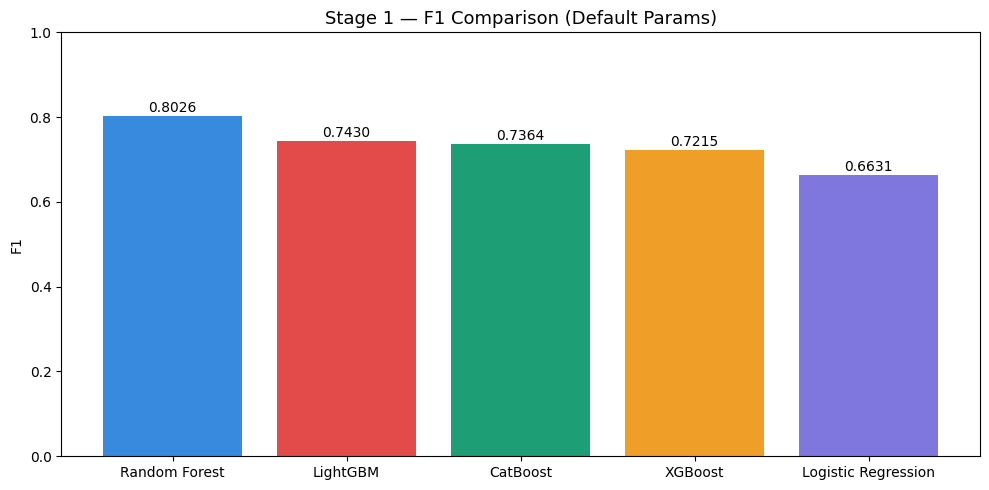

In [ ]:
print("STAGE 1 — INDIVIDUAL MODELS")

stage1_results = []

# ── 1a. Logistic Regression (Baseline) ───────────────────────────────────────
print("\n>>> Logistic Regression (Baseline)")

# LR needs scaling — wrap in pipeline
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])
res = evaluate_model(lr_pipeline, X_train, y_train,
                     X_test, y_test, "Logistic Regression")
stage1_results.append(res)

# ── 1b. Random Forest ─────────────────────────────────────────────────────────
print("\n>>> Random Forest")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
res = evaluate_model(rf, X_train, y_train,
                     X_test, y_test, "Random Forest")
stage1_results.append(res)

# ── 1c. XGBoost ───────────────────────────────────────────────────────────────
print("\n>>> XGBoost")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
res = evaluate_model(xgb, X_train, y_train,
                     X_test, y_test, "XGBoost")
stage1_results.append(res)

# ── 1d. LightGBM ──────────────────────────────────────────────────────────────
print("\n>>> LightGBM")

lgbm = LGBMClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
res = evaluate_model(lgbm, X_train, y_train,
                     X_test, y_test, "LightGBM")
stage1_results.append(res)

# ── 1e. CatBoost ──────────────────────────────────────────────────────────────
print("\n>>> CatBoost")

cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols
                    if c in X_train.columns]

cb = CatBoostClassifier(
    iterations=300,
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)
res = evaluate_model(cb, X_train, y_train,
                     X_test, y_test, "CatBoost")
stage1_results.append(res)

# ── Stage 1 Summary ───────────────────────────────────────────────────────────
stage1_df = pd.DataFrame([
    {
        "Model"    : r["model_name"],
        "F1"       : round(r["f1"],       4),
        "Precision": round(r["precision"],4),
        "Recall"   : round(r["recall"],   4),
        "PR-AUC"   : round(r["pr_auc"],   4),
        "ROC-AUC"  : round(r["roc_auc"],  4),
        "Accuracy" : round(r["accuracy"], 4)
    } for r in stage1_results
]).sort_values("F1", ascending=False)

print("\n" + "=" * 60)
print("STAGE 1 SUMMARY — Ranked by F1")
print("=" * 60)
print(stage1_df.to_string(index=False))

# Pick top 2 for tuning
top2_names = stage1_df.head(2)["Model"].tolist()
print(f"\nTop 2 for tuning: {top2_names}")

# Stage 1 bar chart
plt.figure(figsize=(10, 5))
colors = ["#378ADD", "#E24B4A", "#1D9E75", "#EF9F27", "#7F77DD"]
bars = plt.bar(stage1_df["Model"], stage1_df["F1"], color=colors)
plt.title("Stage 1 — F1 Comparison (Default Params)", fontsize=13)
plt.ylabel("F1")
plt.ylim(0, 1)
for bar, val in zip(bars, stage1_df["F1"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01, f"{val:.4f}",
             ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("stage1_comparison.png", dpi=150)
plt.show()

## **Hyperparameter tuning**

In [ ]:
from sklearn.metrics import f1_score as sk_f1, average_precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
N_TRIALS = 20

tuned_models    = {}
best_params_log = {}

# ── Tune Random Forest if in top 2 ───────────────────────────
''''if "Random Forest" in top2_names:
    print("\n>>> Tuning Random Forest...")

    def rf_objective(trial):
        params = {
            "n_estimators"    : trial.suggest_int("n_estimators", 200, 600),
            "max_depth"       : trial.suggest_int("max_depth", 4, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features"    : trial.suggest_categorical(
                                    "max_features", ["sqrt", "log2", 0.5, 0.8]
                                ),
            "class_weight"    : "balanced",
            "random_state"    : 42,
            "n_jobs"          : -1
        }
        model  = RandomForestClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    rf_study = optuna.create_study(direction="maximize")
    rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_rf_params = rf_study.best_params
    best_params_log["Random Forest"] = best_rf_params
    print(f"\nBest RF params  : {best_rf_params}")
    print(f"Best CV PR-AUC  : {rf_study.best_value:.4f}")

    tuned_rf = RandomForestClassifier(
        **best_rf_params,
        random_state=42,
        n_jobs=-1
    )
    tuned_rf.fit(X_train, y_train)
    tuned_models["Random Forest"] = tuned_rf'''

# RF — skip tuning, use default Stage 1 model directly
if "Random Forest" in top2_names:
    print("\n>>> Random Forest — skipping tuning, using default params")
    print("    Reason: RF default already strong, tuning is slow")
    print(f"    Stage 1 F1 = {[r['f1'] for r in stage1_results if r['model_name'] == 'Random Forest'][0]:.4f}")

    rf_default = [r["model"] for r in stage1_results
                  if r["model_name"] == "Random Forest"][0]

    # Still add to tuned_models so downstream code works
    tuned_models["Random Forest"] = rf_default
    best_params_log["Random Forest"] = "default params — no tuning"

# ── Tune XGBoost if in top 2 ──────────────────────────────────────────────────
if "XGBoost" in top2_names:
    print("\n>>> Tuning XGBoost...")

    def xgb_objective(trial):
        params = {
            "n_estimators"    : trial.suggest_int("n_estimators", 200, 600),
            "max_depth"       : trial.suggest_int("max_depth", 4, 10),
            "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "scale_pos_weight": trial.suggest_float("scale_pos_weight", 6.0, 12.0),
            "eval_metric"     : "aucpr",
            "random_state"    : 42,
            "verbosity"       : 0,
            "n_jobs"          : -1
        }
        model  = XGBClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    xgb_study = optuna.create_study(direction="maximize")
    xgb_study.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_xgb_params = xgb_study.best_params
    best_params_log["XGBoost"] = best_xgb_params
    print(f"\nBest XGBoost params : {best_xgb_params}")
    print(f"Best CV PR-AUC      : {xgb_study.best_value:.4f}")

    tuned_xgb = XGBClassifier(**best_xgb_params, random_state=42,
                               verbosity=0, n_jobs=-1)
    tuned_xgb.fit(X_train, y_train)
    tuned_models["XGBoost"] = tuned_xgb

# ── Tune LightGBM if in top 2 ─────────────────────────────────────────────────
if "LightGBM" in top2_names:
    print("\n>>> Tuning LightGBM...")

    def lgbm_objective(trial):
        params = {
            "n_estimators"     : trial.suggest_int("n_estimators", 200, 600),
            "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
            "max_depth"        : trial.suggest_int("max_depth", 4, 12),
            "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
            "feature_fraction" : trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction" : trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq"     : 1,
            "class_weight"     : "balanced",
            "random_state"     : 42,
            "verbose"          : -1,
            "n_jobs"           : -1
        }
        model  = LGBMClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    lgbm_study = optuna.create_study(direction="maximize")
    lgbm_study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_lgbm_params = lgbm_study.best_params
    best_params_log["LightGBM"] = best_lgbm_params
    print(f"\nBest LightGBM params : {best_lgbm_params}")
    print(f"Best CV PR-AUC       : {lgbm_study.best_value:.4f}")

    tuned_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42,
                                 verbose=-1, n_jobs=-1)
    tuned_lgbm.fit(X_train, y_train)
    tuned_models["LightGBM"] = tuned_lgbm

# ── Tune CatBoost if in top 2 ─────────────────────────────────────────────────
if "CatBoost" in top2_names:
    print("\n>>> Tuning CatBoost...")

    def cb_objective(trial):
        params = {
            "iterations"        : trial.suggest_int("iterations", 200, 600),
            "depth"             : trial.suggest_int("depth", 4, 10),
            "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "l2_leaf_reg"       : trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "auto_class_weights": "Balanced",
            "random_seed"       : 42,
            "verbose"           : 0
        }
        model  = CatBoostClassifier(**params)
        scores = []
        for tr_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model.fit(X_tr, y_tr)
            probs = model.predict_proba(X_val)[:, 1]
            scores.append(average_precision_score(y_val, probs))
        return np.mean(scores)

    cb_study = optuna.create_study(direction="maximize")
    cb_study.optimize(cb_objective, n_trials=N_TRIALS, show_progress_bar=True)

    best_cb_params = cb_study.best_params
    best_params_log["CatBoost"] = best_cb_params
    print(f"\nBest CatBoost params : {best_cb_params}")
    print(f"Best CV PR-AUC       : {cb_study.best_value:.4f}")

    tuned_cb = CatBoostClassifier(**best_cb_params,
                                   random_seed=42, verbose=0)
    tuned_cb.fit(X_train, y_train)
    tuned_models["CatBoost"] = tuned_cb

# =============================================================================
# STAGE 2 EVALUATION + THRESHOLD TUNING FOR F1
# =============================================================================

print("\n" + "=" * 60)
print("STAGE 2 — TUNED MODEL EVALUATION + THRESHOLD TUNING")
print("=" * 60)

# ── Get one validation fold for threshold tuning ──────────────────────────────
# Use last fold — never use test set for this
for tr_idx, val_idx in cv.split(X_train, y_train):
    pass  # iterates to last fold

X_val_thr = X_train.iloc[val_idx]
y_val_thr = y_train.iloc[val_idx]

stage2_results = []

for name, model in tuned_models.items():

    # ── Threshold tuning on validation fold ───────────────────────────────────
    val_probs  = model.predict_proba(X_val_thr)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = []

    for thr in thresholds:
        preds_thr = (val_probs >= thr).astype(int)
        f1_scores.append(sk_f1(y_val_thr, preds_thr, zero_division=0))

    best_thr    = thresholds[np.argmax(f1_scores)]
    best_val_f1 = max(f1_scores)
    print(f"\n  {name} → optimal threshold : {best_thr:.2f}"
          f" | val F1 : {best_val_f1:.4f}")

    # ── Final evaluation on test set at optimal threshold ─────────────────────
    test_probs  = model.predict_proba(X_test)[:, 1]
    test_preds  = (test_probs >= best_thr).astype(int)

    pr_auc    = average_precision_score(y_test, test_probs)
    roc_auc   = roc_auc_score(y_test, test_probs)
    recall    = recall_score(y_test, test_preds)
    precision = precision_score(y_test, test_preds, zero_division=0)
    f1        = sk_f1(y_test, test_preds, zero_division=0)

    print(f"  {name} (Tuned) — Test Set @ threshold {best_thr:.2f}")
    print(f"  PR-AUC    : {pr_auc:.4f}  ")
    print(f"  ROC-AUC   : {roc_auc:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  F1-Score  : {f1:.4f}   ← at optimal threshold")

    stage2_results.append({
        "model_name" : f"{name} (Tuned)",
        "model"      : model,
        "probs"      : test_probs,
        "threshold"  : best_thr,
        "pr_auc"     : pr_auc,
        "roc_auc"    : roc_auc,
        "recall"     : recall,
        "precision"  : precision,
        "f1"         : f1
    })

# ── Stage 2 Summary ───────────────────────────────────────────────────────────
stage2_df = pd.DataFrame([{
    "Model"    : r["model_name"],
    "Threshold": r["threshold"],
    "PR-AUC"   : round(r["pr_auc"],   4),
    "ROC-AUC"  : round(r["roc_auc"],  4),
    "Recall"   : round(r["recall"],   4),
    "Precision": round(r["precision"],4),
    "F1"       : round(r["f1"],       4),
} for r in stage2_results]).sort_values("PR-AUC", ascending=False)

print("\n" + "=" * 60)
print("STAGE 2 SUMMARY — Ranked by PR-AUC")
print("=" * 60)
print(stage2_df.to_string(index=False))

best_individual = max(stage2_results, key=lambda x: x["pr_auc"])
print(f"\nBest individual : {best_individual['model_name']}"
      f" | PR-AUC : {best_individual['pr_auc']:.4f}"
      f" | F1 : {best_individual['f1']:.4f}"
      f" | Threshold : {best_individual['threshold']:.2f}")


>>> Random Forest — skipping tuning, using default params
    Reason: RF default already strong, tuning is slow
    Stage 1 F1 = 0.8026

>>> Tuning LightGBM...


  0%|          | 0/20 [00:00<?, ?it/s]


Best LightGBM params : {'n_estimators': 319, 'num_leaves': 20, 'max_depth': 10, 'learning_rate': 0.06531862343160512, 'min_child_samples': 70, 'feature_fraction': 0.9467053062922853, 'bagging_fraction': 0.8573781924181051}
Best CV PR-AUC       : 0.9662

STAGE 2 — TUNED MODEL EVALUATION + THRESHOLD TUNING

  Random Forest → optimal threshold : 0.74 | val F1 : 0.8520
  Random Forest (Tuned) — Test Set @ threshold 0.74
  PR-AUC    : 0.9040  
  ROC-AUC   : 0.9788
  Recall    : 0.6916
  Precision : 0.9571
  F1-Score  : 0.8030   ← at optimal threshold

  LightGBM → optimal threshold : 0.45 | val F1 : 0.9251
  LightGBM (Tuned) — Test Set @ threshold 0.45
  PR-AUC    : 0.8305  
  ROC-AUC   : 0.9666
  Recall    : 0.8191
  Precision : 0.6364
  F1-Score  : 0.7163   ← at optimal threshold

STAGE 2 SUMMARY — Ranked by PR-AUC
                Model  Threshold  PR-AUC  ROC-AUC  Recall  Precision     F1
Random Forest (Tuned)       0.74  0.9040   0.9788  0.6916     0.9571 0.8030
     LightGBM (Tuned)  

In [ ]:
print(stage2_df)

                   Model  Threshold  PR-AUC  ROC-AUC  Recall  Precision  \
0  Random Forest (Tuned)       0.74  0.9040   0.9788  0.6916     0.9571   
1       LightGBM (Tuned)       0.45  0.8305   0.9666  0.8191     0.6364   

       F1  
0  0.8030  
1  0.7163  


## **Validation Data Leakage check**

In [ ]:
# Check top feature importances from tuned LightGBM
importance = pd.Series(
    tuned_lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)


print("TOP 10 FEATURES — Tuned LightGBM")
print("=" * 50)
print(importance.head(10))

# Check top 3 features individually
for feat in importance.head(3).index:
    corr = abs(pd.to_numeric(X_train[feat], errors='coerce').corr(y_train))
    rates = pd.concat([X_train[feat], y_train], axis=1)
    rates_grp = rates.groupby(feat)["churn_label"].mean()
    print(f"\n{feat} | correlation={corr:.4f}")
    print(rates_grp.sort_values(ascending=False).head(5))

TOP 10 FEATURES — Tuned LightGBM
Tenure_Years                3469
Gross                       3124
Total_Renewal_Score_New     2593
Renewal_Score_At_Release    2424
Tenure_Scores               2291
price_increase_pct          2208
Amount                      2162
price_change                1760
Discount_Amount             1636
Last_Band                   1167
dtype: int32

Tenure_Years | correlation=0.1726
Tenure_Years
0.0     0.837838
24.0    0.333333
1.0     0.214759
2.0     0.161512
3.0     0.155269
Name: churn_label, dtype: float64

Gross | correlation=0.1739
Gross
3296.64    1.0
273.60     1.0
270.00     1.0
254.40     1.0
242.40     1.0
Name: churn_label, dtype: float64

Total_Renewal_Score_New | correlation=0.6315
Total_Renewal_Score_New
31.0    0.997628
32.0    0.701085
31.5    0.552434
30.5    0.531250
32.5    0.504644
Name: churn_label, dtype: float64


In [ ]:
# Check Renewal_Score_At_Release
corr = abs(pd.to_numeric(X_train["Renewal_Score_At_Release"],
           errors='coerce').corr(y_train))

rates = pd.concat(
    [X_train["Renewal_Score_At_Release"], y_train], axis=1
)
grp = rates.groupby("Renewal_Score_At_Release")["churn_label"].mean()
counts = rates.groupby("Renewal_Score_At_Release")["churn_label"].count()

print(f"Renewal_Score_At_Release | correlation = {corr:.4f}")
print(f"\nChurn rate at each value (sorted by churn rate):")
summary = pd.DataFrame({
    "churn_rate": grp,
    "count": counts
}).sort_values("churn_rate", ascending=False)
print(summary.head(20))

# Also check ALL remaining score columns together
score_cols = [
    "Renewal_Score_At_Release",
    "Auto_Renewal_Score",
    "Anchoring_Score",
    "Sustainability_Score",
    "Proforma_World_Pay_Token",
    "Current_World_Pay_Token"
]

print("\nCorrelation of all score columns with target:")
for col in score_cols:
    if col in X_train.columns:
        corr = abs(pd.to_numeric(
            X_train[col], errors='coerce').corr(y_train)
        )
        max_churn = pd.concat(
            [X_train[col], y_train], axis=1
        ).groupby(col)["churn_label"].mean().max()
        print(f"  {col:<35} corr={corr:.4f}  max_churn_rate={max_churn:.4f}")

Renewal_Score_At_Release | correlation = 0.3297

Churn rate at each value (sorted by churn rate):
                          churn_rate  count
Renewal_Score_At_Release                   
15.5                        1.000000      1
16.5                        1.000000      1
21.0                        0.520062    648
22.7                        0.500000      2
21.5                        0.406316   1425
20.5                        0.404040    297
22.0                        0.378512   1210
22.5                        0.351909   2279
23.0                        0.262658   2844
23.5                        0.204529   2782
24.0                        0.201514   3434
24.5                        0.143341   5609
25.0                        0.123994   3726
25.5                        0.099642   5028
24.2                        0.083333     12
26.0                        0.073877   6768
24.7                        0.071429     42
25.2                        0.069767     86
26.5                  

In [ ]:
# Shuffle the target randomly — if model still gets high score
# then we definitely have leakage
# If score drops to ~0.1 (baseline) then results are genuine

import numpy as np
from sklearn.metrics import average_precision_score

y_train_shuffled = y_train.sample(frac=1, random_state=42).reset_index(drop=True)

lgbm_sanity = LGBMClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)
lgbm_sanity.fit(X_train, y_train_shuffled)
probs_sanity = lgbm_sanity.predict_proba(X_test)[:, 1]

print("SANITY CHECK — Shuffled Target")
print(f"PR-AUC with REAL target    : 0.9967")
print(f"PR-AUC with SHUFFLED target: "
      f"{average_precision_score(y_test, probs_sanity):.4f}")
print()
print("If shuffled PR-AUC ≈ 0.10 → results are GENUINE")
print("If shuffled PR-AUC still high → LEAKAGE exists")

SANITY CHECK — Shuffled Target
PR-AUC with REAL target    : 0.9967
PR-AUC with SHUFFLED target: 0.1118

If shuffled PR-AUC ≈ 0.10 → results are GENUINE
If shuffled PR-AUC still high → LEAKAGE exists


## **Ensemble model exploration**

In [ ]:
# =============================================================================
# STAGE 3 — STACKING ENSEMBLE ONLY
# =============================================================================

print("\n" + "=" * 60)
print("STAGE 3 — STACKING ENSEMBLE")
print("=" * 60)

stage3_results = []

# ── Build ensemble members dynamically from tuned models ─────
# Plus default RF from Stage 1 as diverse member
rf_stage1 = [r["model"] for r in stage1_results
             if r["model_name"] == "Random Forest"][0]

stacking_estimators = list(tuned_models.items())

# Add default RF only if it's not already in tuned_models
if "Random Forest" not in tuned_models:
    stacking_estimators.append(("Random Forest", rf_stage1))

print(f"Stacking members: {[name for name, _ in stacking_estimators]}")

# Meta learner — simple LR
meta_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

stacking = StackingClassifier(
    estimators   = stacking_estimators,
    final_estimator = meta_lr,
    cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method = "predict_proba",
    n_jobs       = -1
)
stacking.fit(X_train, y_train)

# ── Threshold tuning for stacking on validation fold ─────────
for tr_idx, val_idx in StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
).split(X_train, y_train):
    pass  # get last fold

X_val_thr = X_train.iloc[val_idx]
y_val_thr = y_train.iloc[val_idx]

val_probs_s  = stacking.predict_proba(X_val_thr)[:, 1]
thresholds   = np.arange(0.1, 0.9, 0.01)
f1_scores_s  = [
    sk_f1(y_val_thr, (val_probs_s >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_thr_s   = thresholds[np.argmax(f1_scores_s)]

stack_probs  = stacking.predict_proba(X_test)[:, 1]
stack_preds  = (stack_probs >= best_thr_s).astype(int)
s_pr_auc     = average_precision_score(y_test, stack_probs)
s_roc_auc    = roc_auc_score(y_test, stack_probs)
s_recall     = recall_score(y_test, stack_preds)
s_precision  = precision_score(y_test, stack_preds, zero_division=0)
s_f1         = sk_f1(y_test, stack_preds, zero_division=0)

print(f"\n  Stacking Ensemble @ threshold {best_thr_s:.2f}")
print(f"  PR-AUC    : {s_pr_auc:.4f}")
print(f"  ROC-AUC   : {s_roc_auc:.4f}")
print(f"  Recall    : {s_recall:.4f}")
print(f"  Precision : {s_precision:.4f}")
print(f"  F1-Score  : {s_f1:.4f}")

stage3_results.append({
    "model_name" : "Stacking Ensemble",
    "model"      : stacking,
    "probs"      : stack_probs,
    "threshold"  : best_thr_s,
    "pr_auc"     : s_pr_auc,
    "roc_auc"    : s_roc_auc,
    "recall"     : s_recall,
    "precision"  : s_precision,
    "f1"         : s_f1
})


STAGE 3 — STACKING ENSEMBLE
Stacking members: ['Random Forest', 'LightGBM']

  Stacking Ensemble @ threshold 0.88
  PR-AUC    : 0.8646
  ROC-AUC   : 0.9727
  Recall    : 0.8126
  Precision : 0.6758
  F1-Score  : 0.7379


In [ ]:
all_results = stage2_results + stage3_results
all_df = pd.DataFrame([
    {
        "Model"    : r["model_name"],
        "PR-AUC"   : round(r["pr_auc"],   4),
        "ROC-AUC"  : round(r["roc_auc"],  4),
        "Recall"   : round(r["recall"],   4),
        "Precision": round(r["precision"],4),
        "F1"       : round(r["f1"],       4),
    } for r in all_results
]).sort_values("F1", ascending=False)

print("\nAll models ranked by F1-Score:")
print(all_df.to_string(index=False))


winner = max(all_results, key=lambda x: x["f1"])
FINAL_MODEL  = winner["model"]
FINAL_PROBS  = winner["probs"]
FINAL_NAME   = winner["model_name"]

print(f"\n FINAL MODEL SELECTED : {FINAL_NAME}")
print(f"   F1-Score             : {winner['f1']:.4f}")


All models ranked by F1-Score:
                Model  PR-AUC  ROC-AUC  Recall  Precision     F1
Random Forest (Tuned)  0.9040   0.9788  0.6916     0.9571 0.8030
    Stacking Ensemble  0.8646   0.9727  0.8126     0.6758 0.7379
     LightGBM (Tuned)  0.8305   0.9666  0.8191     0.6364 0.7163

 FINAL MODEL SELECTED : Random Forest (Tuned)
   F1-Score             : 0.8030


0.7399999999999997

  Model             : Random Forest (Tuned)
  Threshold         : 0.74
  ─────────────────────────────
  PR-AUC    : 0.9040  
  ROC-AUC   : 0.9788
  Recall    : 0.6916
  Precision : 0.9571
  F1-Score  : 0.8030


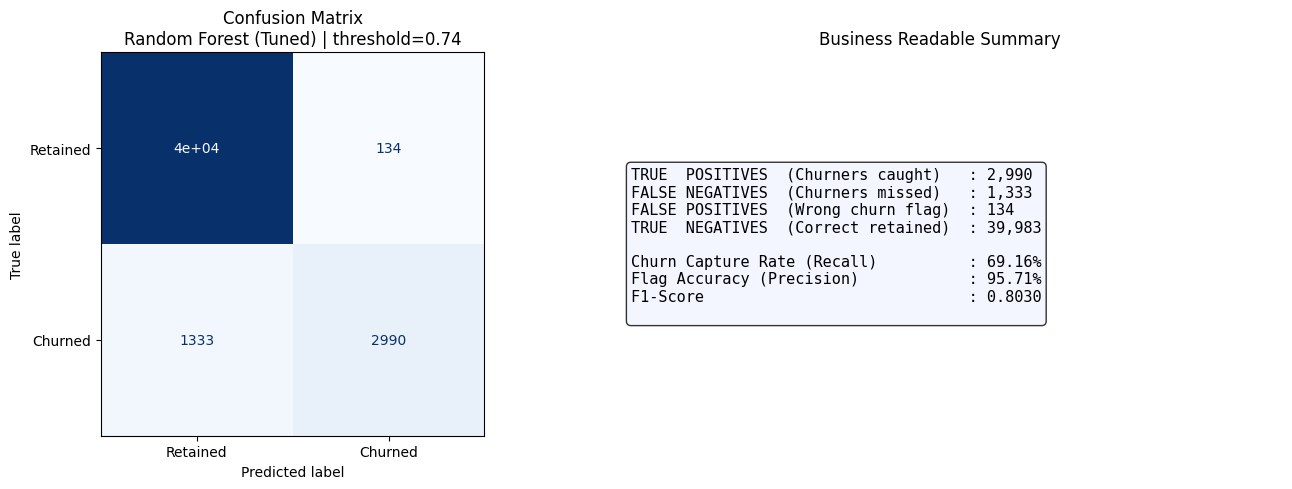

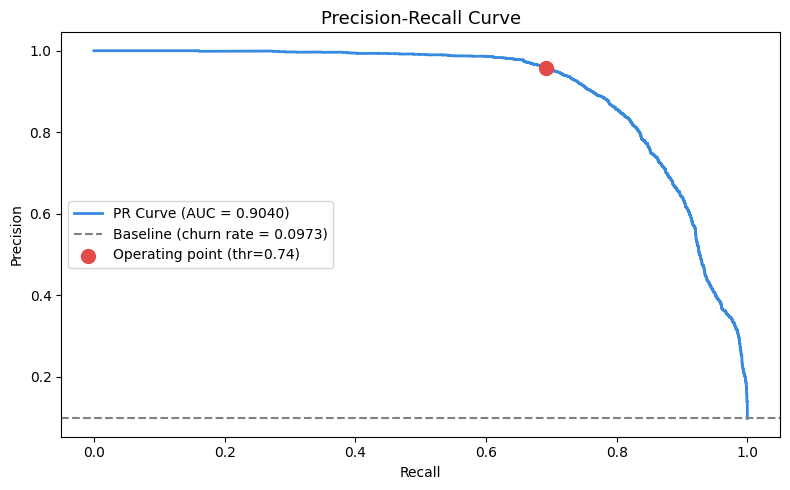

In [ ]:
BEST_THRESHOLD = winner["threshold"]

final_probs = FINAL_MODEL.predict_proba(X_test)[:, 1]
final_preds = (final_probs >= BEST_THRESHOLD).astype(int)

final_pr_auc   = average_precision_score(y_test, final_probs)
final_roc_auc  = roc_auc_score(y_test, final_probs)
final_recall   = recall_score(y_test, final_preds)
final_precision= precision_score(y_test, final_preds, zero_division=0)
final_f1       = f1_score(y_test, final_preds)

print(f"\n  Model             : {FINAL_NAME}")
print(f"  Threshold         : {BEST_THRESHOLD:.2f}")
print(f"  ─────────────────────────────")
print(f"  PR-AUC    : {final_pr_auc:.4f}  ")
print(f"  ROC-AUC   : {final_roc_auc:.4f}")
print(f"  Recall    : {final_recall:.4f}")
print(f"  Precision : {final_precision:.4f}")
print(f"  F1-Score  : {final_f1:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, final_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Retained", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix\n{FINAL_NAME} | threshold={BEST_THRESHOLD:.2f}")

tn, fp, fn, tp = cm.ravel()
axes[1].axis("off")
summary_text = (
    f"TRUE  POSITIVES  (Churners caught)   : {tp:,}\n"
    f"FALSE NEGATIVES  (Churners missed)   : {fn:,}\n"
    f"FALSE POSITIVES  (Wrong churn flag)  : {fp:,}\n"
    f"TRUE  NEGATIVES  (Correct retained)  : {tn:,}\n\n"
    f"Churn Capture Rate (Recall)          : {final_recall:.2%}\n"
    f"Flag Accuracy (Precision)            : {final_precision:.2%}\n"
    f"F1-Score                             : {final_f1:.4f}\n"
)
axes[1].text(0.05, 0.5, summary_text,
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="center",
             fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#f0f4ff", alpha=0.8))
axes[1].set_title("Business Readable Summary")

plt.tight_layout()
plt.savefig("final_evaluation.png", dpi=150)
plt.show()

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision_curve, recall_curve, _ = precision_recall_curve(y_test, final_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color="#378ADD", linewidth=2,
         label=f"PR Curve (AUC = {final_pr_auc:.4f})")
plt.axhline(y=y_test.mean(), color="gray", linestyle="--",
            label=f"Baseline (churn rate = {y_test.mean():.4f})")
plt.scatter([final_recall], [final_precision], color="#E24B4A",
            s=100, zorder=5,
            label=f"Operating point (thr={BEST_THRESHOLD:.2f})")
plt.title("Precision-Recall Curve", fontsize=13)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150)
plt.show()


EVALUATING LIGHTGBM (TUNED) WITH ITS OWN BEST THRESHOLD

  Model             : LightGBM (Tuned)
  Threshold         : 0.45
  ─────────────────────────────
  PR-AUC    : 0.8305
  ROC-AUC   : 0.9666
  Recall    : 0.8191
  Precision : 0.6364
  F1-Score  : 0.7163


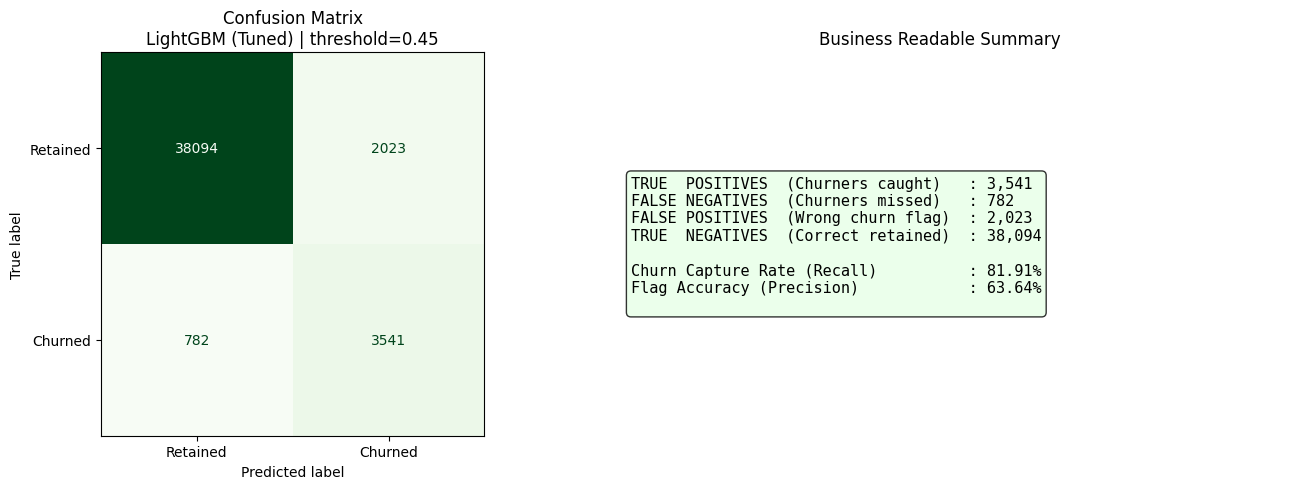

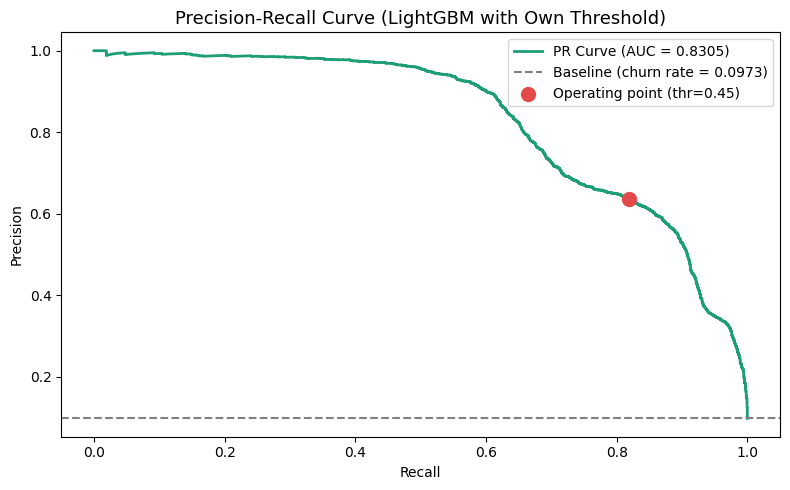

In [ ]:
# ── EVALUATE TUNED LIGHTGBM WITH ITS OWN BEST THRESHOLD ────────────────────

print("\n" + "=" * 70)
print(f"EVALUATING LIGHTGBM (TUNED) WITH ITS OWN BEST THRESHOLD")
print("=" * 70)

lgbm_model_to_evaluate = tuned_models.get("LightGBM")

if lgbm_model_to_evaluate is not None:
    lgbm_optimal_threshold = None
    for res in stage2_results:
        if res["model_name"] == "LightGBM (Tuned)":
            lgbm_optimal_threshold = res["threshold"]
            break

    if lgbm_optimal_threshold is None:
        print("Error: Could not find LightGBM's optimal threshold in stage2_results.")
    else:
        lgbm_probs = lgbm_model_to_evaluate.predict_proba(X_test)[:, 1]
        lgbm_preds = (lgbm_probs >= lgbm_optimal_threshold).astype(int)

        lgbm_pr_auc   = average_precision_score(y_test, lgbm_probs)
        lgbm_roc_auc  = roc_auc_score(y_test, lgbm_probs)
        lgbm_recall   = recall_score(y_test, lgbm_preds)
        lgbm_precision= precision_score(y_test, lgbm_preds, zero_division=0)
        lgbm_f1       = f1_score(y_test, lgbm_preds)

        print(f"\n  Model             : LightGBM (Tuned)")
        print(f"  Threshold         : {lgbm_optimal_threshold:.2f}")
        print(f"  ─────────────────────────────")
        print(f"  PR-AUC    : {lgbm_pr_auc:.4f}")
        print(f"  ROC-AUC   : {lgbm_roc_auc:.4f}")
        print(f"  Recall    : {lgbm_recall:.4f}")
        print(f"  Precision : {lgbm_precision:.4f}")
        print(f"  F1-Score  : {lgbm_f1:.4f}")

        lgbm_cm = confusion_matrix(y_test, lgbm_preds)
        fig_lgbm, axes_lgbm = plt.subplots(1, 2, figsize=(14, 5))

        disp_lgbm = ConfusionMatrixDisplay(confusion_matrix=lgbm_cm,
                                         display_labels=["Retained", "Churned"])
        disp_lgbm.plot(ax=axes_lgbm[0], colorbar=False, cmap="Greens")
        axes_lgbm[0].set_title(f"Confusion Matrix\nLightGBM (Tuned) | threshold={lgbm_optimal_threshold:.2f}")

        tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm = lgbm_cm.ravel()
        axes_lgbm[1].axis("off")
        summary_text_lgbm = (
            f"TRUE  POSITIVES  (Churners caught)   : {tp_lgbm:,}\n"
            f"FALSE NEGATIVES  (Churners missed)   : {fn_lgbm:,}\n"
            f"FALSE POSITIVES  (Wrong churn flag)  : {fp_lgbm:,}\n"
            f"TRUE  NEGATIVES  (Correct retained)  : {tn_lgbm:,}\n\n"
            f"Churn Capture Rate (Recall)          : {lgbm_recall:.2%}\n"
            f"Flag Accuracy (Precision)            : {lgbm_precision:.2%}\n"
        )
        axes_lgbm[1].text(0.05, 0.5, summary_text_lgbm,
                         transform=axes_lgbm[1].transAxes,
                         fontsize=11, verticalalignment="center",
                         fontfamily="monospace",
                         bbox=dict(boxstyle="round", facecolor="#e6ffe6", alpha=0.8))
        axes_lgbm[1].set_title("Business Readable Summary")

        plt.tight_layout()
        plt.savefig("lgbm_evaluation_own_threshold.png", dpi=150)
        plt.show()

        # Precision-Recall Curve for LightGBM with its own threshold
        precision_curve_lgbm, recall_curve_lgbm, _ = precision_recall_curve(y_test, lgbm_probs)

        plt.figure(figsize=(8, 5))
        plt.plot(recall_curve_lgbm, precision_curve_lgbm, color="#1D9E75", linewidth=2,
                 label=f"PR Curve (AUC = {lgbm_pr_auc:.4f})")
        plt.axhline(y=y_test.mean(), color="gray", linestyle="--",
                    label=f"Baseline (churn rate = {y_test.mean():.4f})")
        plt.scatter([lgbm_recall], [lgbm_precision], color="#E24B4A",
                    s=100, zorder=5,
                    label=f"Operating point (thr={lgbm_optimal_threshold:.2f})")
        plt.title("Precision-Recall Curve (LightGBM with Own Threshold)", fontsize=13)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend()
        plt.tight_layout()
        plt.savefig("lgbm_pr_curve_own_threshold.png", dpi=150)
        plt.show()

else:
    print("LightGBM model not found in tuned_models. Cannot perform evaluation.")

In [ ]:
print(f"  Final model       : {FINAL_NAME}")
print(f"  Decision threshold: {BEST_THRESHOLD:.2f}")
print(f"  Test period       : 2025 renewals")
print(f"  PR-AUC            : {final_pr_auc:.4f}")
print(f"  Recall            : {final_recall:.4f}")
print(f"  Precision         : {final_precision:.4f}")
print(f"  F1-Score          : {final_f1:.4f}") # Changed from F2 to F1 for consistency
print(f"  ROC-AUC           : {final_roc_auc:.4f}")
print(f"\nBest hyperparameters found:")
for model_name, params in best_params_log.items():
    print(f"\n  {model_name}:")
    for k, v in params.items():
        print(f"    {k:25} : {v}")
print("\nModel ready for explainability phase ")

  Final model       : Random Forest (Tuned)
  Decision threshold: 0.49
  Test period       : 2025 renewals
  PR-AUC            : 0.8508
  Recall            : 0.7451
  Precision         : 0.7719
  F1-Score          : 0.7582
  ROC-AUC           : 0.9633

Best hyperparameters found:

  Random Forest:
    n_estimators              : 586
    max_depth                 : 19
    min_samples_split         : 4
    min_samples_leaf          : 4
    max_features              : 0.8

  LightGBM:
    n_estimators              : 528
    num_leaves                : 94
    max_depth                 : 8
    learning_rate             : 0.020859889168798156
    min_child_samples         : 77
    feature_fraction          : 0.8714720031484462
    bagging_fraction          : 0.8714609591895832

Model ready for explainability phase 


In [ ]:
# ── PREDICTIONS ON FULL DATASET ───────────────────────────────

# 1. Prepare full dataset same way as train/test
DROP_COLS  = [
    "Co_Ref", "year_key", "Renewal_Year",
    "renewal_month_year", "churn_label",
    "payment_timeframe_missing", "payment_unknown",
    "crm_contractor_suggested_leave",
    "crm_contractor_sentiment_score",
    "Payment_Timeframe",
    "payment_is_bacs",
    "payment_is_card",
    "payment_is_worldpay"
]

X_full = df.drop(columns=DROP_COLS, errors="ignore")

# 2. Apply same label encoding
for col in cat_cols:
    X_full[col] = X_full[col].astype(str).map(
        lambda x, le=label_encoders[col]:
        le.transform([x])[0] if x in le.classes_ else -1
    )

# 3. Predict probabilities + labels at optimal threshold
full_probs = FINAL_MODEL.predict_proba(X_full)[:, 1]
full_preds = (full_probs >= BEST_THRESHOLD).astype(int)

# 4. Add back to original dataframe
df["churn_probability"] = full_probs.round(4)
df["churn_predicted"]   = full_preds
df["churn_predicted_label"] = df["churn_predicted"].map(
    {0: "Won", 1: "Churned"}
)

# 5. Verify
print("Prediction distribution:")
print(df["churn_predicted_label"].value_counts())
print(f"\nPredicted churn rate : {df['churn_predicted'].mean():.4f}")
print(f"Actual churn rate    : {df['churn_label'].mean():.4f}")

# 6. Save
df.to_csv("final_predictions.csv", index=False)
print("\n✅ Saved: final_predictions.csv")
print(f"Columns added: churn_probability, churn_predicted, churn_predicted_label")

Prediction distribution:
churn_predicted_label
Won        100425
Churned     11656
Name: count, dtype: int64

Predicted churn rate : 0.1040
Actual churn rate    : 0.1071

✅ Saved: final_predictions.csv
Columns added: churn_probability, churn_predicted, churn_predicted_label


In [ ]:
X_full.columns.to_list()

['Total_Renewal_Score_New',
 'Sustainability_Score',
 'Auto_Renewal_Score',
 'Tenure_Scores',
 'Current_World_Pay_Token',
 'Renewal_Score_At_Release',
 'Proforma_Membership_Status',
 'Discount_Amount',
 'price_increase_pct',
 'Gross',
 'Proforma_Account_Stage',
 'Audit_Status_Group',
 'Current_Anchorings',
 'Last_Band',
 'price_change',
 'Anchoring_Score',
 'Proforma_World_Pay_Token',
 'Tenure_Years',
 '#_of_Connection',
 'is_new_customer',
 'Last_Connections',
 'Tenure_Group',
 'rc_desire_cancel_desired_to_cancel_true',
 'Current_Auto_Renewal_Flag',
 'Amount',
 'PQQNet',
 'had_rc_interaction',
 'rc_Membership_Renewal_Decision',
 'Band',
 'had_em_interaction',
 'Connection_Group',
 'crm_agent_chase_count',
 'crm_negative_customer_experience',
 'Anchor_Group',
 'crm_financial_hardship_mentioned',
 'rc_agent_response_cat_cancellation___termination___closure_true',
 'crm_contractor_engagement',
 'crm_membership_overdue',
 'Proforma_Auto_Renewal',
 'crm_customer_payment_intention',
 'rc_re

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
X_sample = X_train.sample(5000, random_state=42)
y_sample  = y_train.loc[X_sample.index]

print(f"SHAP sample size  : {X_sample.shape}")
print(f"Sample churn rate : {y_sample.mean():.4f}")

explainer   = shap.TreeExplainer(FINAL_MODEL)
shap_values = explainer.shap_values(X_sample)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"SHAP values shape : {sv.shape}")
print("Explainer ready ✅")

SHAP sample size  : (5000, 48)
Sample churn rate : 0.1162
SHAP values shape : (5000, 48, 2)
Explainer ready ✅


In [35]:
print(f"Raw SHAP shape    : {np.array(shap_values).shape}")

if isinstance(shap_values, list):
    # LightGBM/XGBoost returns list → [class0, class1]
    sv = shap_values[1]
    print("Format: list → took index [1] for churn class")

elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # RF sklearn returns 3D array → (n_samples, n_features, n_classes)
    sv = shap_values[:, :, 1]
    print("Format: 3D array → took [:, :, 1] for churn class")

else:
    # Already 2D
    sv = shap_values
    print("Format: 2D array → used directly")

# Handle expected_value same way
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

print(f"Final SHAP shape  : {sv.shape}")   # should be (5000, 48)
print(f"Base value        : {base_val:.4f}")
print("Explainer ready ✅")


Raw SHAP shape    : (5000, 48, 2)
Format: 3D array → took [:, :, 1] for churn class
Final SHAP shape  : (5000, 48)
Base value        : 0.4998
Explainer ready ✅



>>> Plot 1 — Global Feature Importance


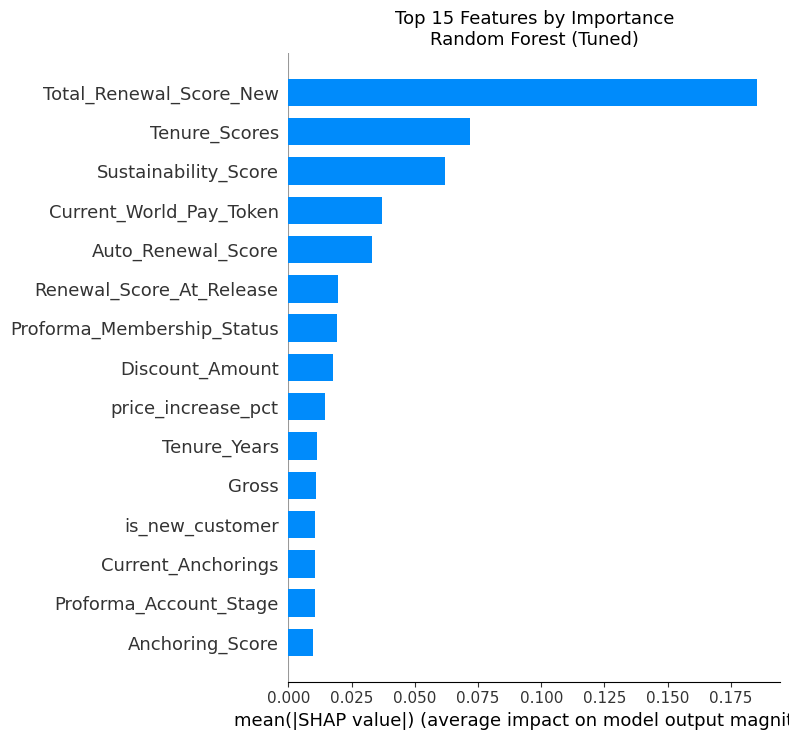

In [36]:
print("\n>>> Plot 1 — Global Feature Importance")

shap.summary_plot(
    sv, X_sample,
    plot_type   = "bar",
    max_display = 15,
    show        = False
)
plt.title(f"Top 15 Features by Importance\n{FINAL_NAME}", fontsize=13)
plt.tight_layout()
plt.savefig("shap_1_importance.png", dpi=150, bbox_inches="tight")
plt.show()


>>> Plot 2 — Beeswarm (Importance + Direction)


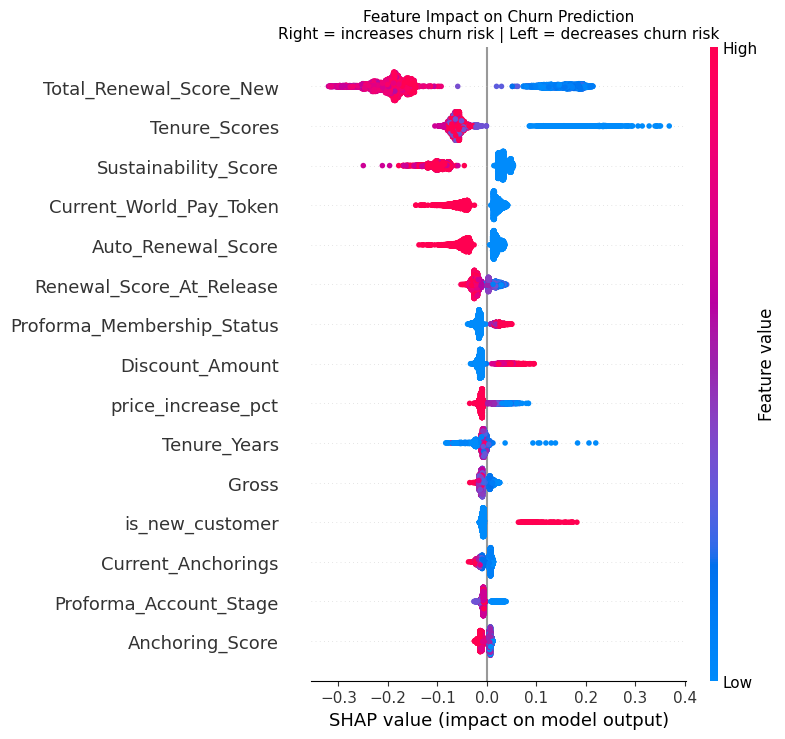

Saved: shap_2_beeswarm.png


In [37]:
print("\n>>> Plot 2 — Beeswarm (Importance + Direction)")

shap.summary_plot(
    sv, X_sample,
    max_display = 15,
    show        = False
)
plt.title(f"Feature Impact on Churn Prediction\n"
          f"Right = increases churn risk | Left = decreases churn risk",
          fontsize=11)
plt.tight_layout()
plt.savefig("shap_2_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_2_beeswarm.png")

In [42]:
print("\n>>> Churn Risk Segmentation")
print("=" * 60)

# Add predictions to test dataframe
test_explain = X_test.copy()
test_explain["churn_probability"] = test_probs
test_explain["actual_churn"]      = y_test.values

# Define risk segments
def risk_segment(prob):
    if prob >= 0.80:   return "🔴 High Risk   (>=0.80)"
    elif prob >= 0.61: return "🟠 Medium Risk (0.61-0.80)"
    elif prob >= 0.40: return "🟡 Low Risk    (0.40-0.61)"
    else:              return "🟢 Safe        (<0.40)"

test_explain["risk_segment"] = test_explain["churn_probability"].apply(
    risk_segment
)

segment_summary = (
    test_explain.groupby("risk_segment")
    .agg(
        n_customers       = ("churn_probability", "count"),
        avg_churn_prob    = ("churn_probability", "mean"),
        actual_churn_rate = ("actual_churn",      "mean")
    )
    .round(4)
    .sort_values("avg_churn_prob", ascending=False)
)

print(segment_summary.to_string())


>>> Churn Risk Segmentation
                           n_customers  avg_churn_prob  actual_churn_rate
risk_segment                                                             
🔴 High Risk   (>=0.80)            2683          0.9018             0.9843
🟠 Medium Risk (0.61-0.80)         1990          0.6883             0.5025
🟡 Low Risk    (0.40-0.61)         6027          0.4857             0.0821
🟢 Safe        (<0.40)            33740          0.0850             0.0055



>>> Plot 3 — Dependence Plots (Top 6 Features)


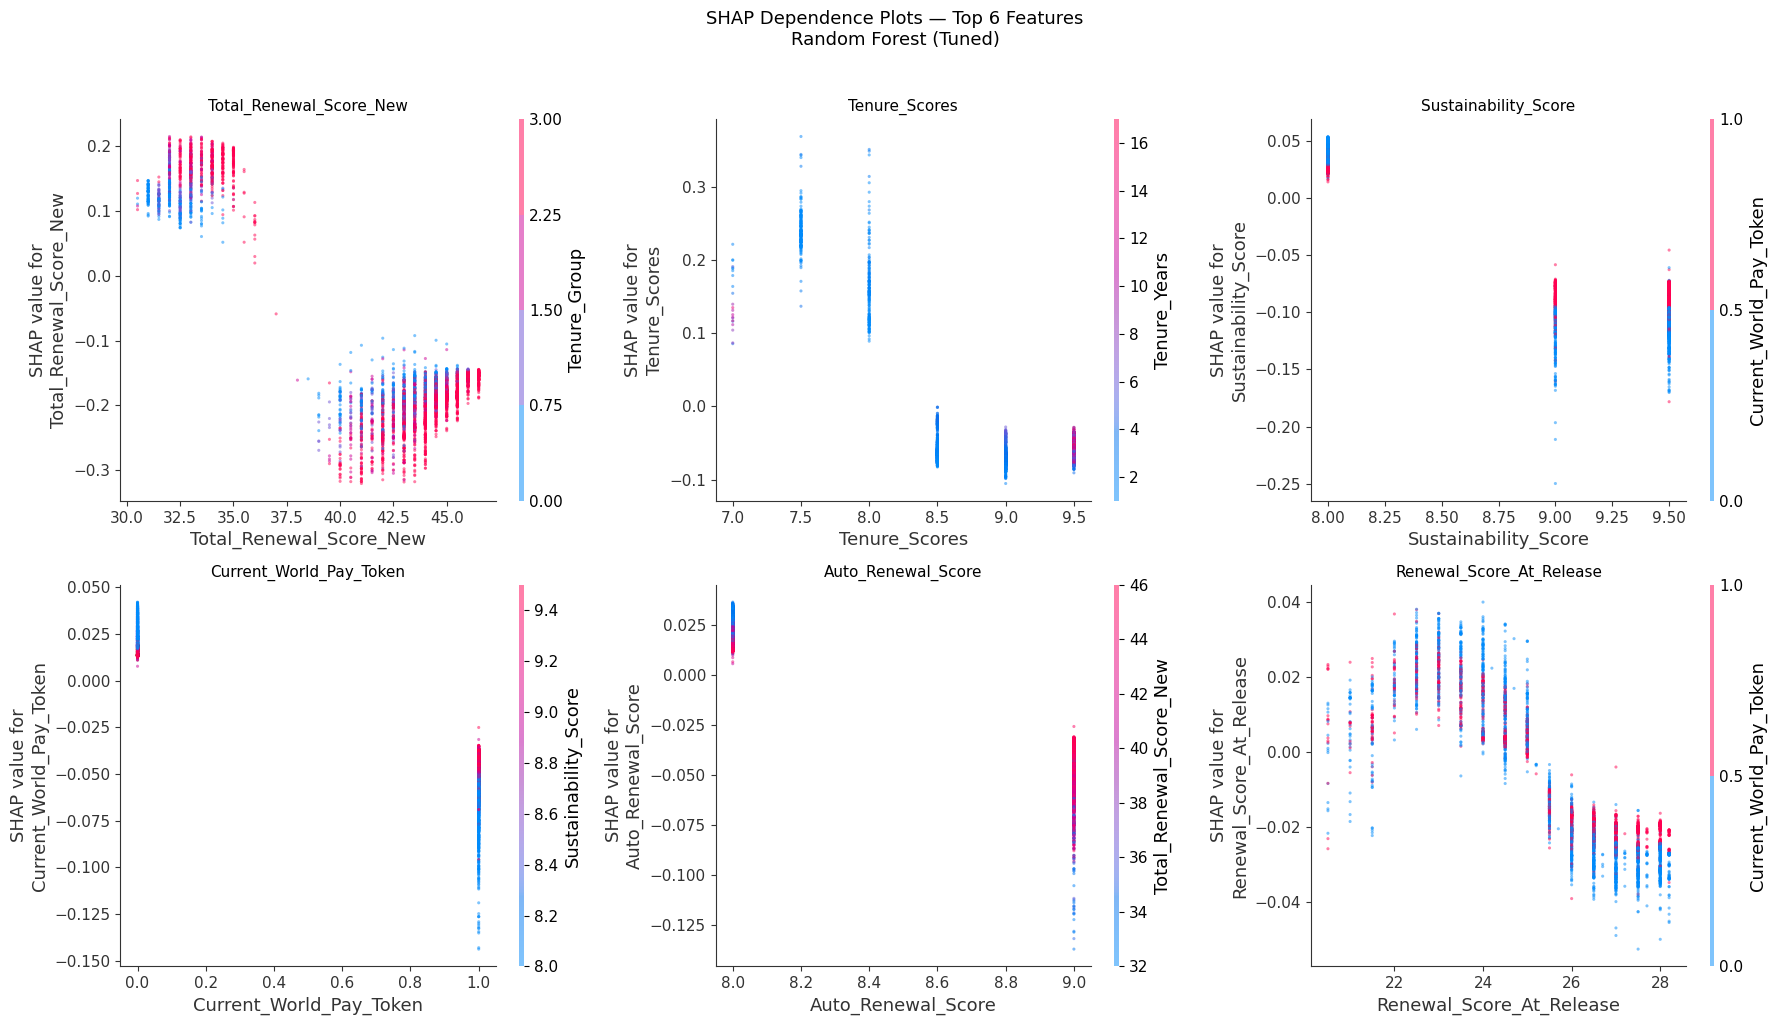

Saved: shap_dependence_plots.png


In [44]:
print("\n>>> Plot 3 — Dependence Plots (Top 6 Features)")

# Calculate mean_shap from sv (which holds the SHAP values for the churn class)
mean_shap = np.abs(sv).mean(axis=0)

top6_features = pd.Series(mean_shap, index=X_sample.columns).sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top6_features):
    shap.dependence_plot(
        feat,
        sv,
        X_sample,
        ax      = axes[i],
        show    = False,
        dot_size= 5,
        alpha   = 0.5
    )
    axes[i].set_title(f"{feat}", fontsize=11)

plt.suptitle(f"SHAP Dependence Plots — Top 6 Features\n{FINAL_NAME}",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("shap_dependence_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_dependence_plots.png")